In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('heart_disease_uci.csv')

In [ ]:
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [ ]:
df.shape #row,column

(920, 16)

In [ ]:
df.columns

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [ ]:
df.dtypes

,0
id,int64
age,int64
sex,object
dataset,object
cp,object
trestbps,float64
chol,float64
fbs,object
restecg,object
thalch,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [ ]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [ ]:
df.drop(['ca', 'thal', 'slope'], axis=1, inplace=True)

In [ ]:
num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']

for col in num_cols:
    df[col] = df[col].fillna(df[col].mean())

In [ ]:
cat_cols = ['fbs', 'restecg', 'exang']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

/tmp/ipykernel_12180/395891159.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


In [ ]:
df.isnull().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0


In [ ]:
df.drop(['id', 'dataset'], axis=1, inplace=True)

In [ ]:
df.rename(columns={
    'num': 'target',
    'thalch': 'thalach'
}, inplace=True)

In [ ]:
df.dtypes

,0
age,int64
sex,object
cp,object
trestbps,float64
chol,float64
fbs,bool
restecg,object
thalach,float64
exang,bool
oldpeak,float64


In [ ]:
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

In [ ]:
df = pd.get_dummies(df, drop_first=True)

In [ ]:
df.head()

,age,trestbps,chol,fbs,thalach,exang,oldpeak,target,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality
0,63,145.0,233.0,True,150.0,False,2.3,0,True,False,False,True,False,False
1,67,160.0,286.0,False,108.0,True,1.5,1,True,False,False,False,False,False
2,67,120.0,229.0,False,129.0,True,2.6,1,True,False,False,False,False,False
3,37,130.0,250.0,False,187.0,False,3.5,0,True,False,True,False,True,False
4,41,130.0,204.0,False,172.0,False,1.4,0,False,True,False,False,False,False


In [ ]:
df.shape

(920, 14)

In [ ]:
df.describe()

,age,trestbps,chol,thalach,oldpeak,target
count,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,53.510870,132.132404,199.130337,137.545665,0.878788,0.553261
std,9.424685,18.443895,108.957634,25.138494,1.053774,0.497426
min,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,177.750000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,221.000000,138.000000,0.800000,1.000000
75%,60.000000,140.000000,267.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,1.000000


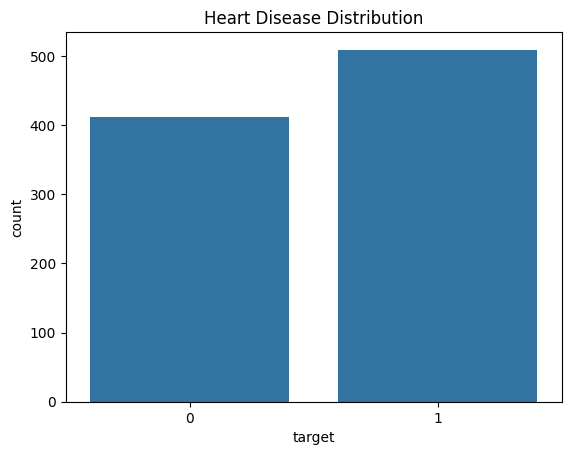

In [ ]:
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.show()

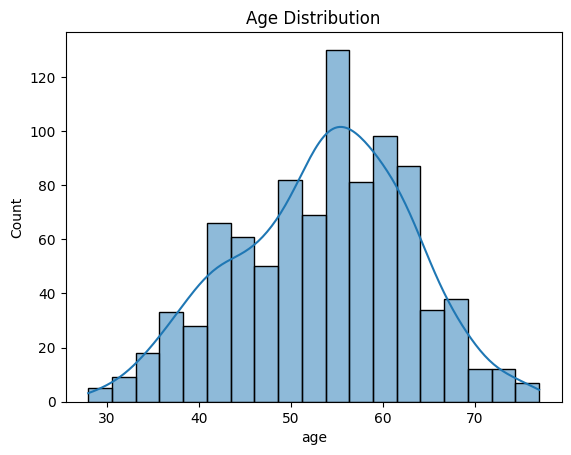

In [ ]:
sns.histplot(df['age'], kde=True)
plt.title("Age Distribution")
plt.show()

In [ ]:
# Most patients fall within middle age group (40–60 years),
# indicating higher occurrence of heart-related issues in this range.

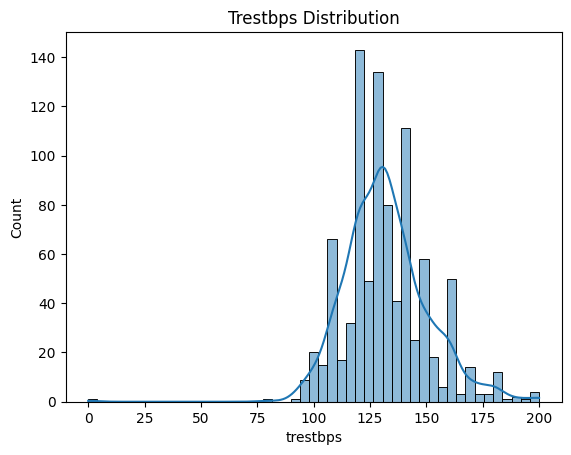

In [ ]:
sns.histplot(df['trestbps'], kde=True)
plt.title("Trestbps Distribution")
plt.show()

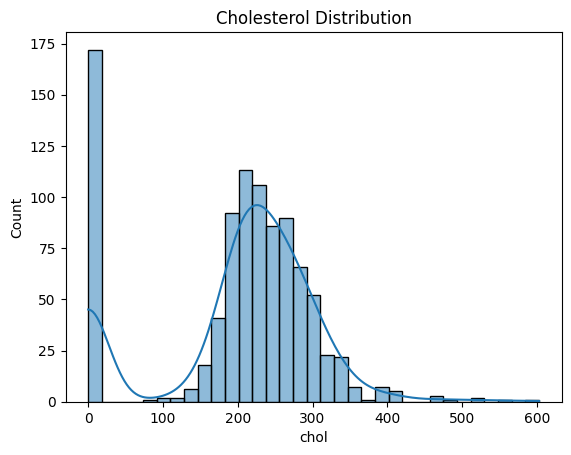

In [ ]:
sns.histplot(df['chol'], kde=True)
plt.title("Cholesterol Distribution")
plt.show()

In [ ]:
# Cholesterol values are widely distributed, with some higher values indicating possible risk,
# but no clear single threshold for disease.

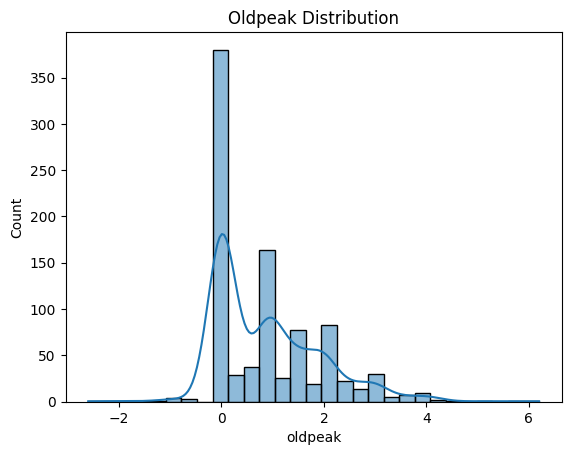

In [ ]:
sns.histplot(df['oldpeak'], kde=True)
plt.title("Oldpeak Distribution")
plt.show()

In [ ]:
# Higher oldpeak values indicate greater ST depression, which is associated with heart disease risk.

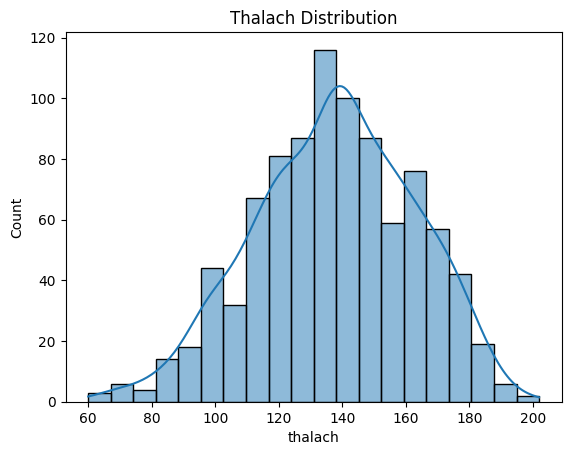

In [ ]:
sns.histplot(df['thalach'], kde=True)
plt.title("Thalach Distribution")
plt.show()

In [ ]:
# Maximum heart rate varies significantly; lower values may indicate poor cardiovascular condition.

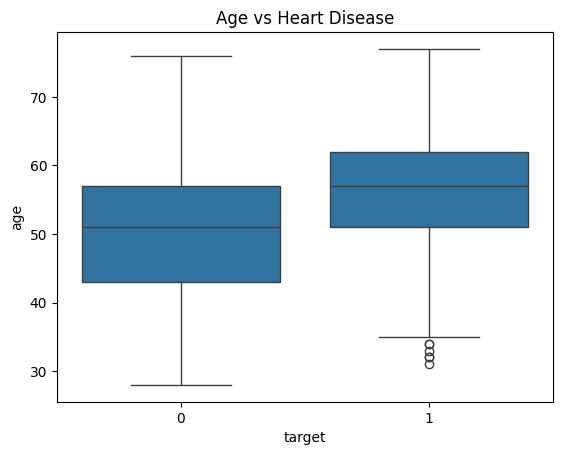

In [ ]:
sns.boxplot(x='target', y='age', data=df)
plt.title("Age vs Heart Disease")
plt.show()

In [ ]:
# Patients with higher age tend to have a higher likelihood of heart disease.

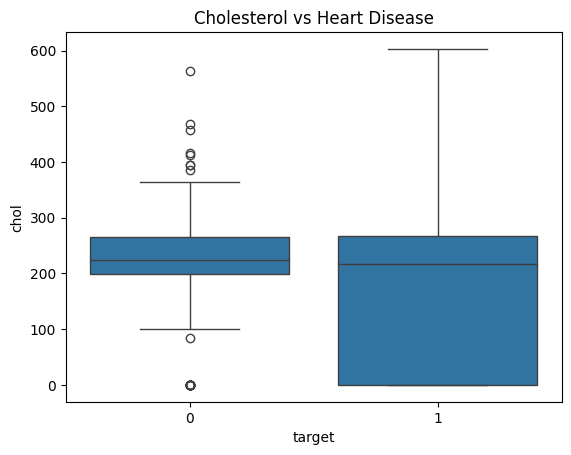

In [ ]:
sns.boxplot(x='target', y='chol', data=df)
plt.title("Cholesterol vs Heart Disease")
plt.show()

In [ ]:
# Cholesterol shows variation across both classes, indicating moderate influence on heart disease.

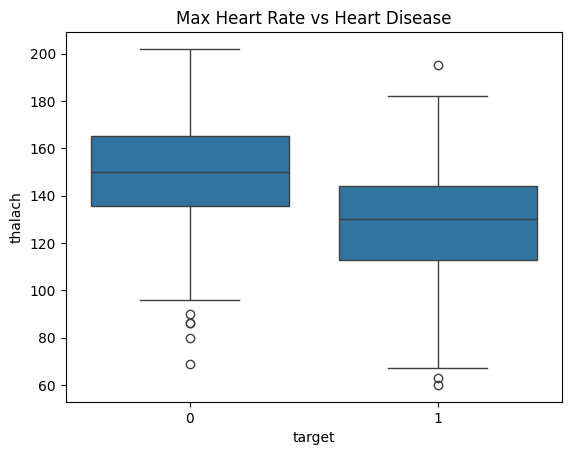

In [ ]:
sns.boxplot(x='target', y='thalach', data=df)
plt.title("Max Heart Rate vs Heart Disease")
plt.show()

In [ ]:
# Patients with lower maximum heart rate are more likely to have heart disease.

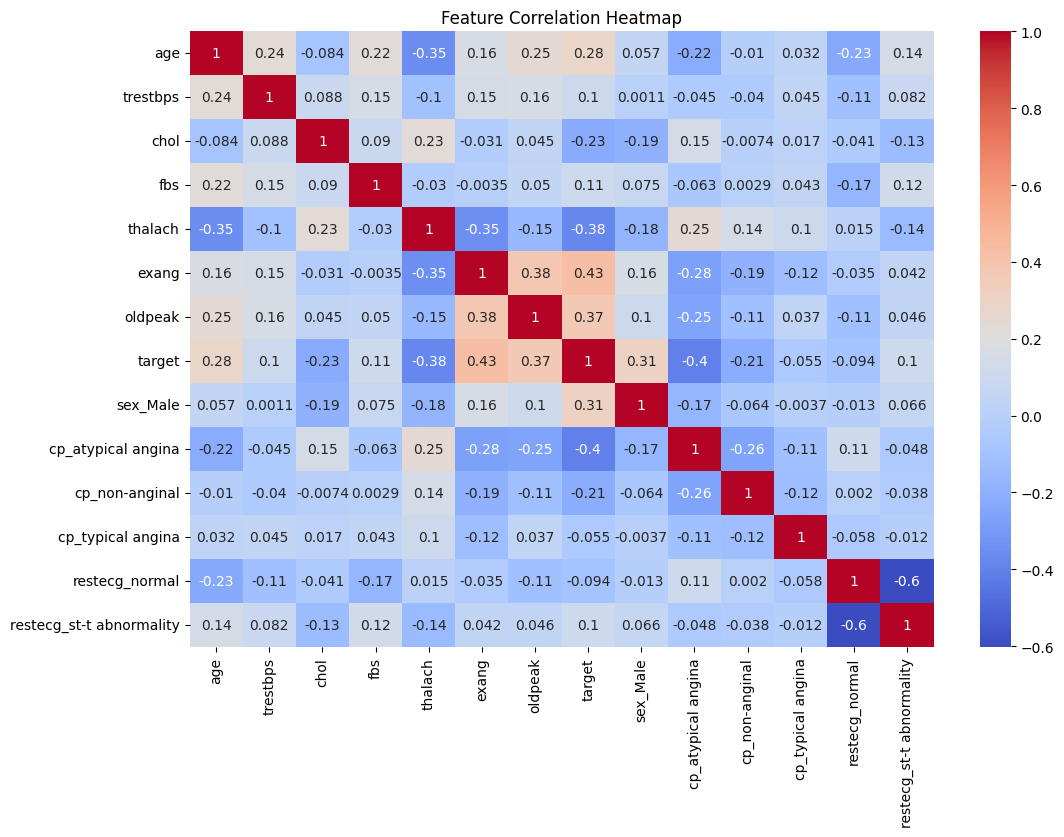

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
# Features like thalach and oldpeak show noticeable correlation with the target variable,
# making them important predictors for heart disease.

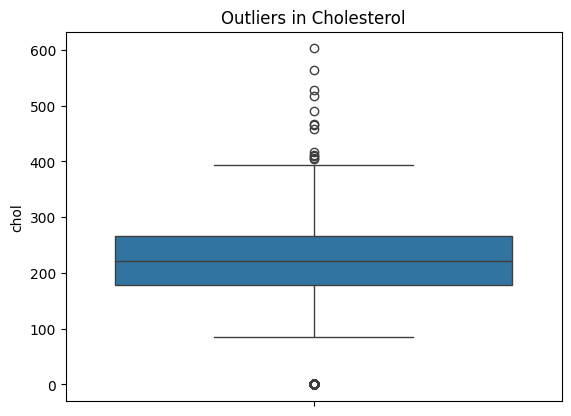

In [ ]:
sns.boxplot(df['chol'])
plt.title("Outliers in Cholesterol")
plt.show()

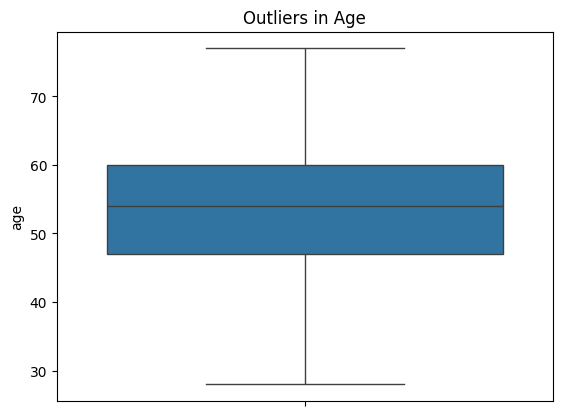

In [ ]:
sns.boxplot(df['age'])
plt.title("Outliers in Age")
plt.show()

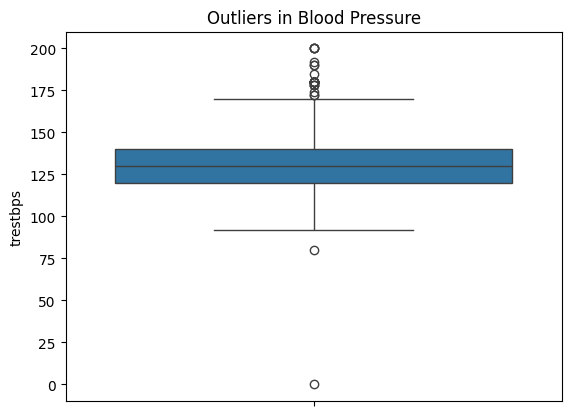

In [ ]:
sns.boxplot(df['trestbps'])
plt.title("Outliers in Blood Pressure")
plt.show()

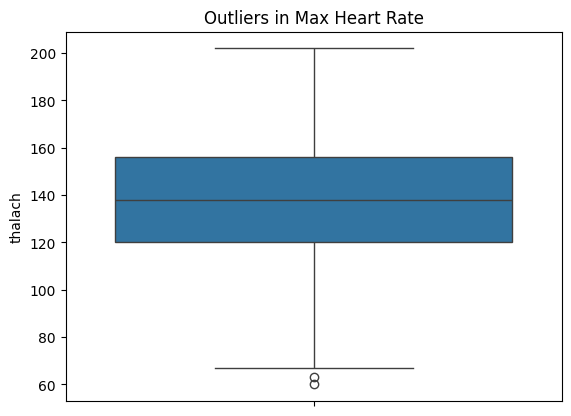

In [ ]:
sns.boxplot(df['thalach'])
plt.title("Outliers in Max Heart Rate")
plt.show()

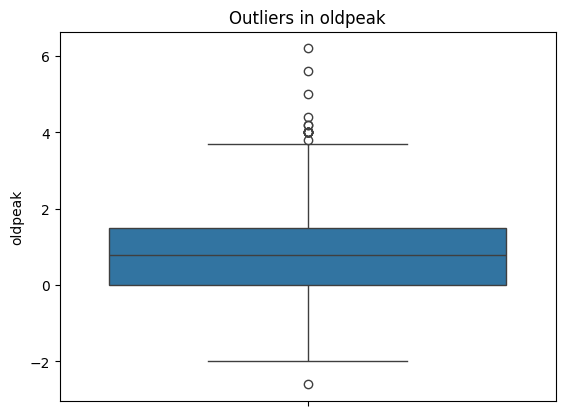

In [ ]:
sns.boxplot(df['oldpeak'])
plt.title("Outliers in oldpeak")
plt.show()

In [ ]:
# Some features contain outliers; however, since this is medical data,
# these extreme values may represent real patient conditions and are retained.

In [ ]:
from scipy import stats
import numpy as np

# Select all numerical and boolean columns for z-score calculation
# Make a copy to convert boolean columns without modifying the original df prematurely
df_for_zscore = df.select_dtypes(include=[np.number, bool]).copy()

# Convert boolean columns to integer (0 or 1)
for col in df_for_zscore.select_dtypes(include=bool).columns:
    df_for_zscore[col] = df_for_zscore[col].astype(int)

# Calculate z-scores on the temporary DataFrame
z = np.abs(stats.zscore(df_for_zscore))

# Identify outliers (rows where any numeric column has a Z-score > 3)
outliers = (z > 3)

print(np.sum(outliers))

65


In [ ]:
df = df.astype({col: 'int' for col in df.select_dtypes('bool').columns})

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])

In [ ]:
from scipy import stats

z = np.abs(stats.zscore(numeric_df))
outliers = (z > 3)

print(np.sum(outliers))

65


In [ ]:
# Some columns contain outliers, but in medical data these may represent real extreme cases,
# so they are not removed to avoid loss of important information.
outlier_count = (z > 3).sum(axis=0)
print(outlier_count)

[ 0  8  3  0  1  0  7  0  0  0  0 46  0  0]


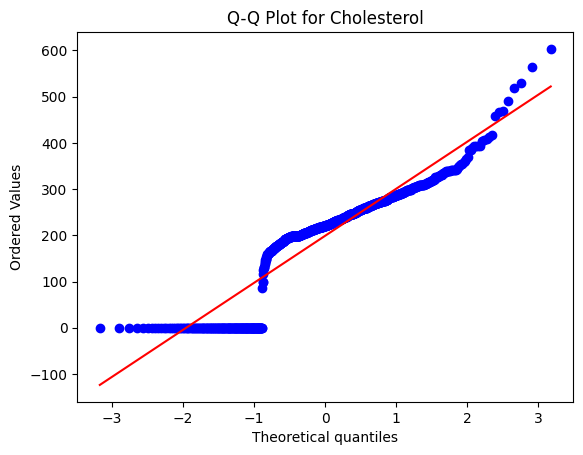

In [ ]:
import scipy.stats as stats

stats.probplot(df['chol'], dist="norm", plot=plt)
plt.title("Q-Q Plot for Cholesterol")
plt.show()

In [ ]:
# Points deviating from the straight line indicate that the data does not perfectly follow a normal distribution.

In [ ]:
X = df.drop('target', axis=1)
y = df['target']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8043478260869565

Confusion Matrix:
 [[60 15]
 [21 88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.80      0.77        75
           1       0.85      0.81      0.83       109

    accuracy                           0.80       184
   macro avg       0.80      0.80      0.80       184
weighted avg       0.81      0.80      0.81       184



In [ ]:
# The Logistic Regression model achieves good accuracy, indicating effective classification of heart disease risk.

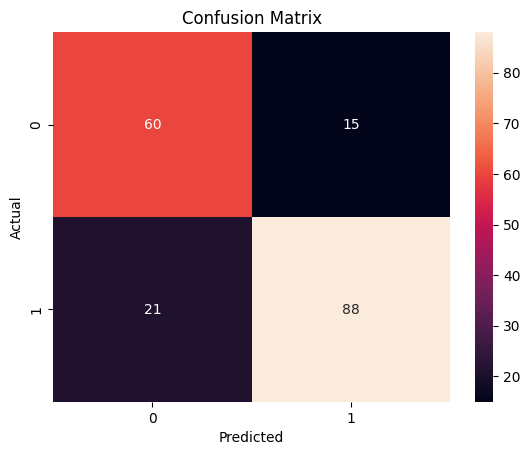

In [ ]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
# The model correctly predicts a majority of cases, though some misclassifications exist,
# which is expected in real-world medical datasets.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7608695652173914


In [ ]:
# Logistic Regression provides stable performance, while Decision Tree may slightly overfit.